<h1><b>LendWise - Predicting Loan Defaults</b></h1>

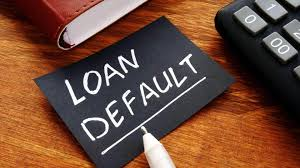

## I. Introduction

Prediction of loan default is a big problem in the financial services sector with implications for financial institutions, banks, and government-sponsored loan programs. There has to be prompt repayment of loans by the borrowers to maintain financial stability and prevent the risk of non-performing loans. But it may be challenging to single out potential risky borrowers due to the inherent difficulty of financial conduct and heterogeneity of determinants of loan repayment.

The goal of this project is to apply machine learning to predict the likelihood of loan default as a function of a very wide set of borrower attributes, e.g., income, credit history, debt-to-income, employment type etc. By enabling high-risk borrowers to be identified with very high accuracy, lending institutions can use targeted intervention, e.g., interest rate modification, money guidance, or loan term adjustment, in an attempt to reduce default rates and maximize financial viability.

The impact of this project is not only on banks. It also benefits borrowers since it enables more fair lending, where individuals are given loans that suit their financial situation. It also benefits policymakers since it enables them to develop better credit risk management systems, which works to develop a healthier financial system in general.

With more data-driven business decision-making being observed within the financial sector, this project particularly aims at the application of predictive analytics within reducing loan defaults, better evaluation of risk models, and simplifying loan approval processes. Through the development of an effective machine learning model, this study will better understand risk profiling of borrowers and more effective and prudent lending.

In this project, we use the [Loan Default Prediction Dataset ](https://www.kaggle.com/datasets/nikhil1e9/loan-default)from Kaggle, which originally comes from Coursera’s Loan Default Prediction Challenge. The dataset contains 255,347 rows and 18 columns, including both numerical and categorical features related to borrower information, loan terms, and payment history.

Our workflow follows a structured data science pipeline:

* EDA: Explored dataset structure, distributions, and class imbalance.

* Feature Engineering: Cleaned and transformed data via scaling, encoding, and feature selection.

* Modeling & Evaluation: Trained Logistic Regression (baseline), Random Forest, and XGBoost, focusing on ROC AUC, F1-score, precision, and recall due to class imbalance. Applied GridSearchCV for hyperparameter tuning.

## II. Import Necessary Python Libraries & The Dataset

We used one CSV for this project, `Loan_default.csv` from a Kaggle [dataset](https://www.kaggle.com/datasets/nikhil1e9/loan-default). The dataset contains a column called `Default`, a binary variable indicating whether a loan was defaulted or not.

To run the notebook, download `Loan_default.csv` from Kaggle and place it in the repository’s `data/` directory. If you are using Google Colab, you may instead upload the CSV directly to `/content/`.


In [ ]:
from pathlib import Path
# import packages
import json
import glob
import pandas as pd
import numpy as np
import datetime as dt
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from sklearn.model_selection import train_test_split
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Locate the dataset when running from the repository root, notebooks/, or Google Colab.
candidate_paths = [
    Path("data/Loan_default.csv"),
    Path("../data/Loan_default.csv"),
    Path("/content/Loan_default.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Download Loan_default.csv from the Kaggle dataset linked above and "
        "place it in the repository data/ directory."
    )

df_defaults = pd.read_csv(data_path)
print(f"Loaded {len(df_defaults):,} records from {data_path}")


In [ ]:
df_defaults.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## III. Exploratory Data Analysis (EDA) & Data Cleaning

Before diving into modeling, we wanted to get a feel for the dataset first. In this section, we examine the structure, distributions, and correlations in the dataset to understand key patterns and identify potential data quality issues such as class imbalance or outliers.


We first used the following commands to get a quick snapshot of the dataset's quality:

1) `info()` shows the shape of the dataset, the datatypes of each column to help us determine numerical vs. categorical features, and if there are any glaring missing values (none apparent)

2) `describe()` shows the distribution of the numerical features to help us see if there are any glaring outliers features such as Income, LoanAmount, CreditScore, etc. (none apparent)

3) `nunique()` helps identify low-cardinality features (ex. binary flags like `HasMortgage`) or potential data errors (ex. `Age` has too many/too few unique values). (none apparent)


In [ ]:
df_defaults.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [ ]:
df_defaults.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [ ]:
df_defaults.nunique()

,0
LoanID,255347
Age,52
Income,114620
LoanAmount,158729
CreditScore,550
MonthsEmployed,120
NumCreditLines,4
InterestRate,2301
LoanTerm,5
DTIRatio,81


We also checked to see if there were any rows that had missing values, if there were any duplicate rows, and if columns like `Age` and `LoanAmount` had any nonsense values (ex. Your age can't be a negative number). We found that the dataset had no issues regarding these checks and that it was already very clean.

In [ ]:
# Check for missing values
num_nulls = df_defaults.isnull().any(axis=1).sum()
print("Rows with missing values:", num_nulls)

Rows with missing values: 0


In [ ]:
# Check for duplicate entries
num_dups = df_defaults.duplicated().sum()
print("Duplicate rows found:", num_dups)

Duplicate rows found: 0


In [ ]:
# Find invalid numerical entries
df_defaults[(df_defaults["Age"] <= 0) | (df_defaults["LoanAmount"] <= 0)]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default


### Distribution of Variables

Next, we wanted to check the distribution of our Target variable, multi-class Categorical features, and Numeric features.

#### Distribution of Target Variable

For our Target Variable, we created a bar chart for the distribution of the `Default` variable. We found a significant class imbalance in favor of loans that were not defaulted (~88%). This led us to consider whether or not we should consider applying resampling techniques on our data before modeling.

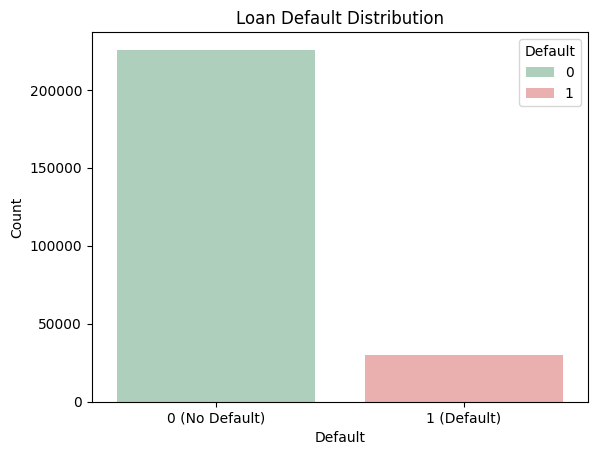

Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64


In [ ]:
custom_palette = {0: "#A8D5BA", 1: "#F4A6A6"}

# Check for class imbalance
ax = sns.countplot(x="Default", data=df_defaults, hue="Default", palette=custom_palette)
ax.set_xlabel("Default")
ax.set_ylabel("Count")
ax.set_title("Loan Default Distribution")

# Change x-axis tick labels
ax.set_xticklabels(["0 (No Default)", "1 (Default)"])

plt.show()

# Print default rate proportions
print(df_defaults['Default'].value_counts(normalize=True))

#### Distribution of Multiclass Categorical Variables

For our multiclass categorical features `LoanPurpose`, `Education`, `MaritalStatus` and `EmploymentType`, we created separate bar charts for each feature to determine the distribution of counts across each of their categories. For all four of these features, we found their distributions to be very equal and level, showing fair representation for each category.

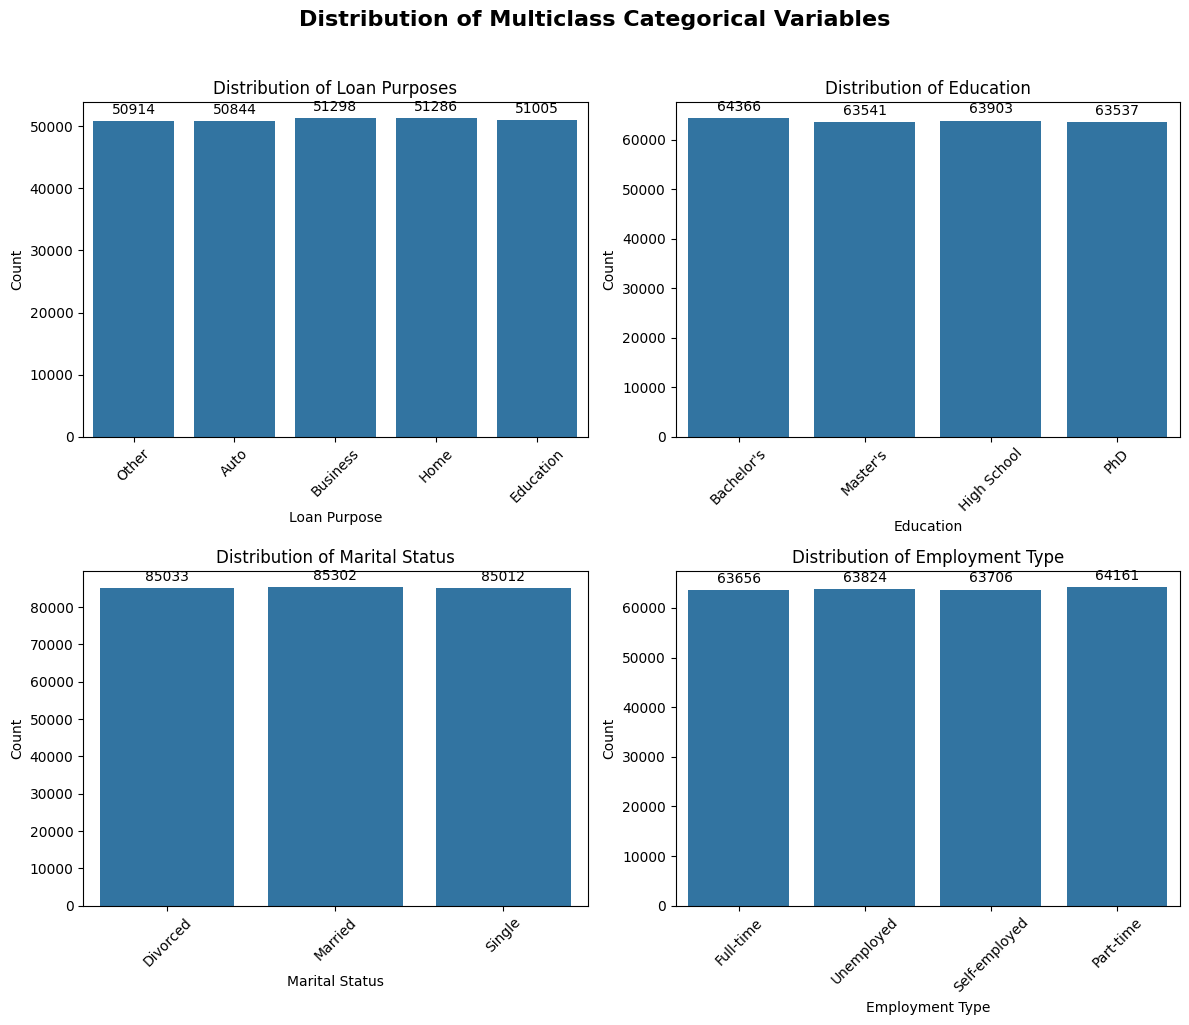

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Distribution of Multiclass Categorical Variables", fontsize=16, fontweight='bold', y=1.02)

# First subplot: Loan Purpose
sns.countplot(x="LoanPurpose", data=df_defaults, ax=axes[0, 0])
axes[0, 0].set_xlabel("Loan Purpose")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of Loan Purposes")
axes[0, 0].tick_params(axis='x', rotation=45)

# add data lables
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 8), textcoords='offset points')

# Second subplot: Education
sns.countplot(x="Education", data=df_defaults, ax=axes[0, 1])
axes[0, 1].set_xlabel("Education")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribution of Education")
axes[0, 1].tick_params(axis='x', rotation=45)

# add data lables
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 8), textcoords='offset points')

# Third subplot: Marital Status
sns.countplot(x="MaritalStatus", data=df_defaults, ax=axes[1, 0])
axes[1, 0].set_xlabel("Marital Status")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Distribution of Marital Status")
axes[1, 0].tick_params(axis='x', rotation=45)

# add data labels
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 8), textcoords='offset points')

# Fourth subplot: Employment Type
sns.countplot(x="EmploymentType", data=df_defaults, ax=axes[1, 1])
axes[1, 1].set_xlabel("Employment Type")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Distribution of Employment Type")
axes[1, 1].tick_params(axis='x', rotation=45)

# add data labels
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

#### Distribution of Numerical Variables

To show the distribution of our numeric features, we plotted histograms with density lines. Once again, for all features we found that the distribution was quite even across all values.

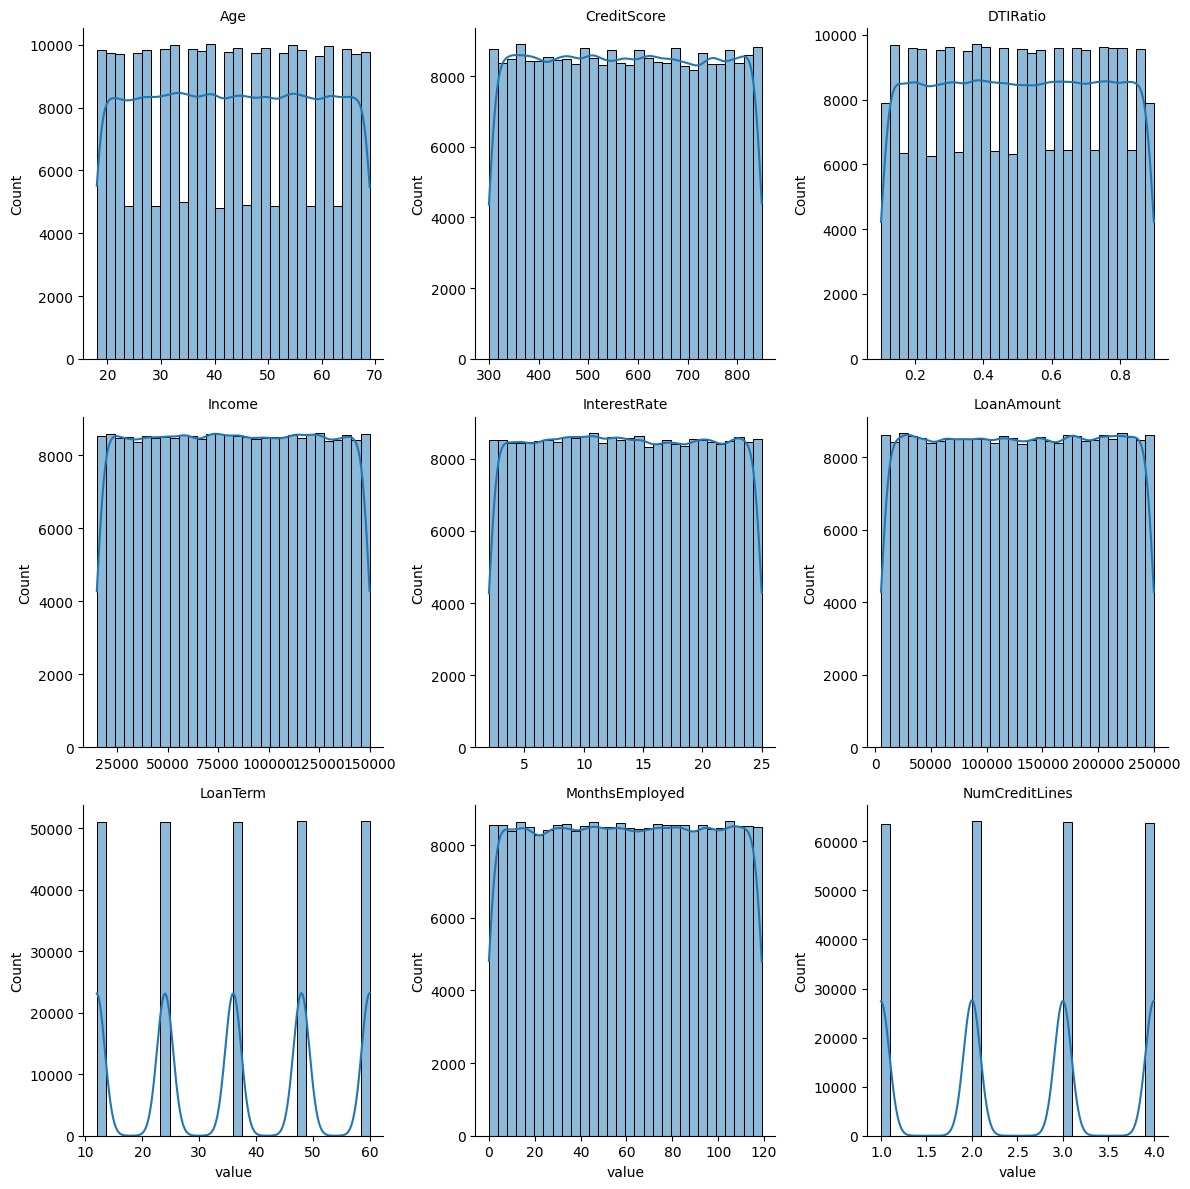

In [ ]:
fig.suptitle("Distribution of Numerical Variables", fontsize=16, fontweight='bold', y=1.02)
numerical_cols = df_defaults.select_dtypes(include=['int', 'float']).columns

numeric_features = numerical_cols.difference(['Default'])
df_melted = df_defaults[numeric_features].melt()

g = sns.FacetGrid(df_melted, col='variable', col_wrap=3, sharex=False, sharey=False, height=4)
g.map(sns.histplot, 'value', bins=30, kde=True)
g.set_titles('{col_name}')
plt.tight_layout()
plt.show()

### Correlation between Numeric Variables

Looking further into our numeric features, we wanted to examine the correlation between each of these variables in creating a correlation heatmap. To do so, we started by filtering our original dataset by dropping `LoanID` (irrelevant for predictions) and `Default` (our target variable), before the splitting our dataset into two separate dataframes of numeric (`numeric_df`) and categorical features (`categorical_df`). Then, we created a correlation matrix from `numeric_df`.

Surprisingly, we found that none of the numeric features had any strong correlation with each other, and all of the correlations were extremely weak/negligible.

In [ ]:
df_filtered = df_defaults.drop(['LoanID','Default'], axis=1)
numeric_df = df_filtered.select_dtypes(include=['int', 'float'])
categorical_df = df_filtered.select_dtypes(include=['object'])

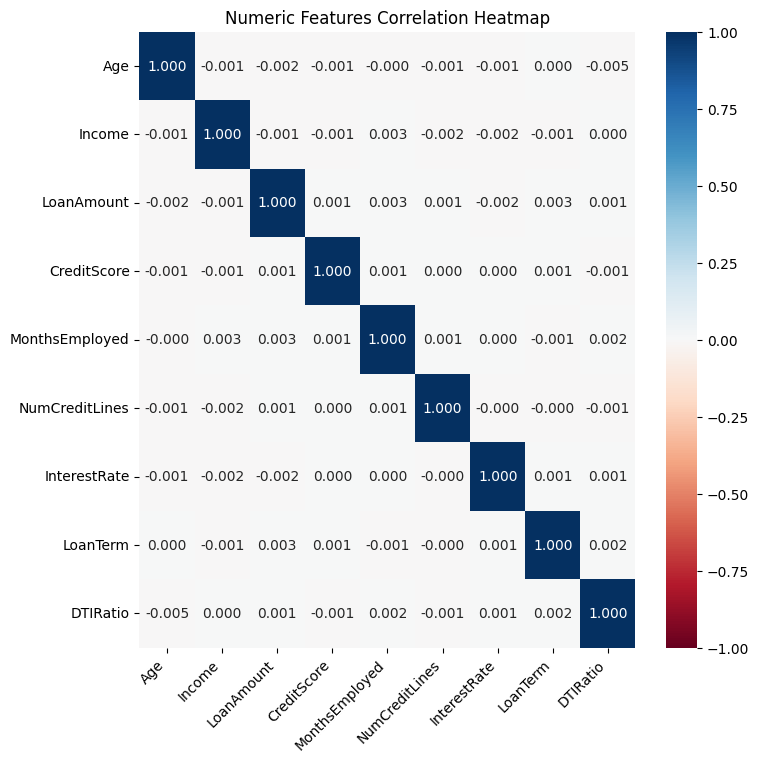

In [ ]:
numeric_corr_mat = numeric_df.corr()

plt.figure(figsize=(8, 8))
sns.heatmap(numeric_corr_mat, fmt=".3f", annot=True, cmap="RdBu", vmin=-1, vmax=1, center=0)
plt.xticks(rotation=45, ha='right')
plt.title('Numeric Features Correlation Heatmap')
plt.show()

### Correlations between Numerical Variables and Target Variable

In a similar vein, we also wanted to check how each of the numeric features correlated with the target variable `Default`. Likewise, we found that none of the numeric features had a strong correlation with our target variable and were all weakly correlated, with `InterestRate` having the strongest positive correlation `Age` having the strongest negative correlation.

In [ ]:
print("Top Correlations with 'Default'")
print(df_defaults[numerical_cols].corr()['Default'].sort_values(ascending=False))

Top Correlations with 'Default'
Default           1.000000
InterestRate      0.131273
LoanAmount        0.086659
NumCreditLines    0.028330
DTIRatio          0.019236
LoanTerm          0.000545
CreditScore      -0.034166
MonthsEmployed   -0.097374
Income           -0.099119
Age              -0.167783
Name: Default, dtype: float64


### Relationship between Input Variables and Target Variable

We were also curious to examine the relationship between Loan Defaults and key financial factors such as `LoanAmount`, `DTIRatio`, `InterestRate`, and `CreditScore`. We created boxplots for each of these features and our target variable `Default`, since significant vertical separation between the boxes might suggest that feature may be predictive of default.

The findings of our boxplots aligned with our expectations: loans that defaulted had a higher distribution in `LoanAmount`, `DTIRatio`, and `InterestRate` values, and a lower distribution in `CreditScore` values.

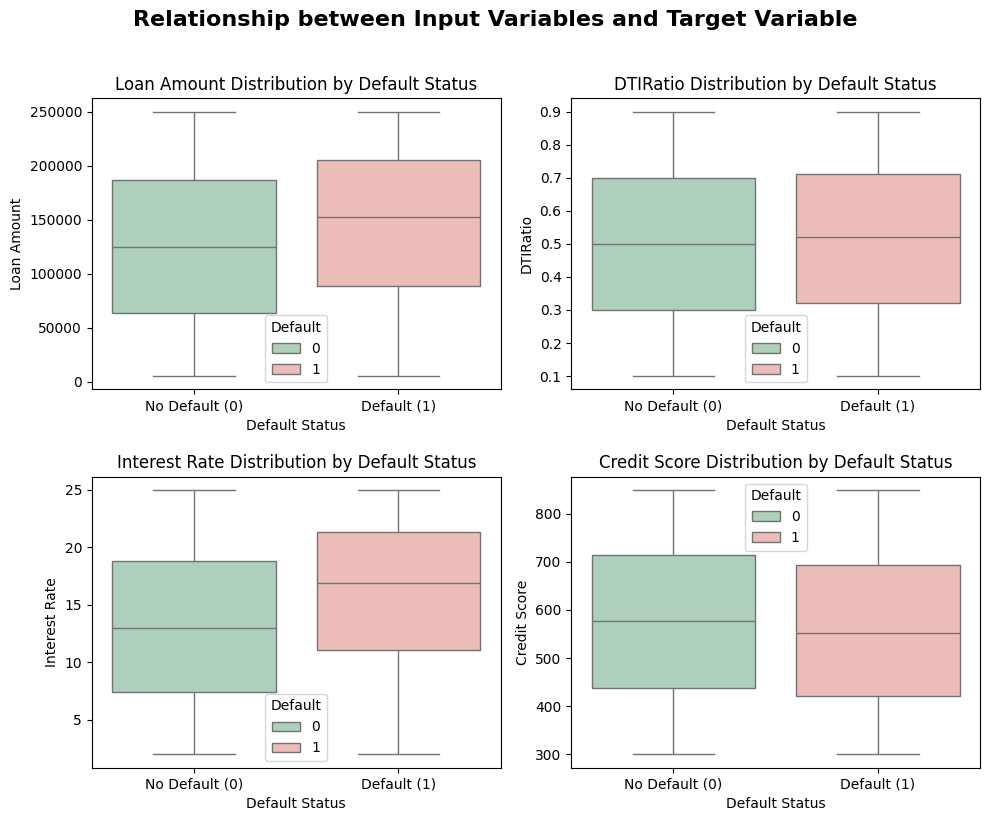

In [ ]:
custom_palette = {0: '#A8D5BA', 1: '#F4B6B0'}  # Soft green for No Default, soft red for Default

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Relationship between Input Variables and Target Variable", fontsize=16, fontweight='bold', y=1.02)

# First subplot: Loan Amount vs Default
sns.boxplot(x="Default", y="LoanAmount", data=df_defaults, hue='Default', ax=axes[0, 0], palette=custom_palette)
axes[0, 0].set_title('Loan Amount Distribution by Default Status')
axes[0, 0].set_xlabel("Default Status")
axes[0, 0].set_ylabel("Loan Amount")
axes[0, 0].set_xticklabels([ "No Default (0)", "Default (1)"])  # Custom x-axis labels

# Second subplot: DTIRatio vs Default
sns.boxplot(x="Default", y="DTIRatio", data=df_defaults, hue='Default', ax=axes[0, 1], palette=custom_palette)
axes[0, 1].set_title('DTIRatio Distribution by Default Status')
axes[0, 1].set_xlabel("Default Status")
axes[0, 1].set_ylabel("DTIRatio")
axes[0, 1].set_xticklabels([ "No Default (0)", "Default (1)"])  # Custom x-axis labels

# Third subplot: Interest Rate vs Default
sns.boxplot(x="Default", y="InterestRate", data=df_defaults, hue='Default', ax=axes[1, 0], palette=custom_palette)
axes[1, 0].set_title('Interest Rate Distribution by Default Status')
axes[1, 0].set_xlabel("Default Status")
axes[1, 0].set_ylabel("Interest Rate")
axes[1, 0].set_xticklabels([ "No Default (0)", "Default (1)"])  # Custom x-axis labels

# Fourth subplot: Credit Score vs Default
sns.boxplot(x="Default", y="CreditScore", data=df_defaults, hue='Default', ax=axes[1, 1], palette=custom_palette)
axes[1, 1].set_title('Credit Score Distribution by Default Status')
axes[1, 1].set_xlabel("Default Status")
axes[1, 1].set_ylabel("Credit Score")
axes[1, 1].set_xticklabels([ "No Default (0)", "Default (1)"])  # Custom x-axis labels

# Adjust layout and add space between rows
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()

Additionally, we wanted to examine the default rates across our multiclass categorical features (`LoanPurpose`, `Education`, `MaritalStatus`, `EmploymentType`) by plotting bar charts of the default rates of each features' categories.

For `LoanPurpose`, we found that Home loans had the lowest default rates, and Business loans had the highest default rates. The fact that homes are an essential purchase and businesses are more speculative ventures may be indicative of their respective default rates.

For `Education`, we found that the lower the borrower's education level, the higher the default rates were. This may suggest that less educated borrowers represent higher default risk.

For `MartialStatus` we found that Married borrowers had the lowest default rates and Divorced borrowers had the highest. The greater financial strain and emotional stress of divorced individuals, and the stability in life circumstances in married individuals may be suggestive of their respective default rates.

For `EmploymentStatus` we found that full-time employed borrowers had the lowest default rates, and unemployed borrowers had the highest default rates. Since full-time employees have higher income stability that unemployed individuals, unemplyed borrowers may represent higher default risk.

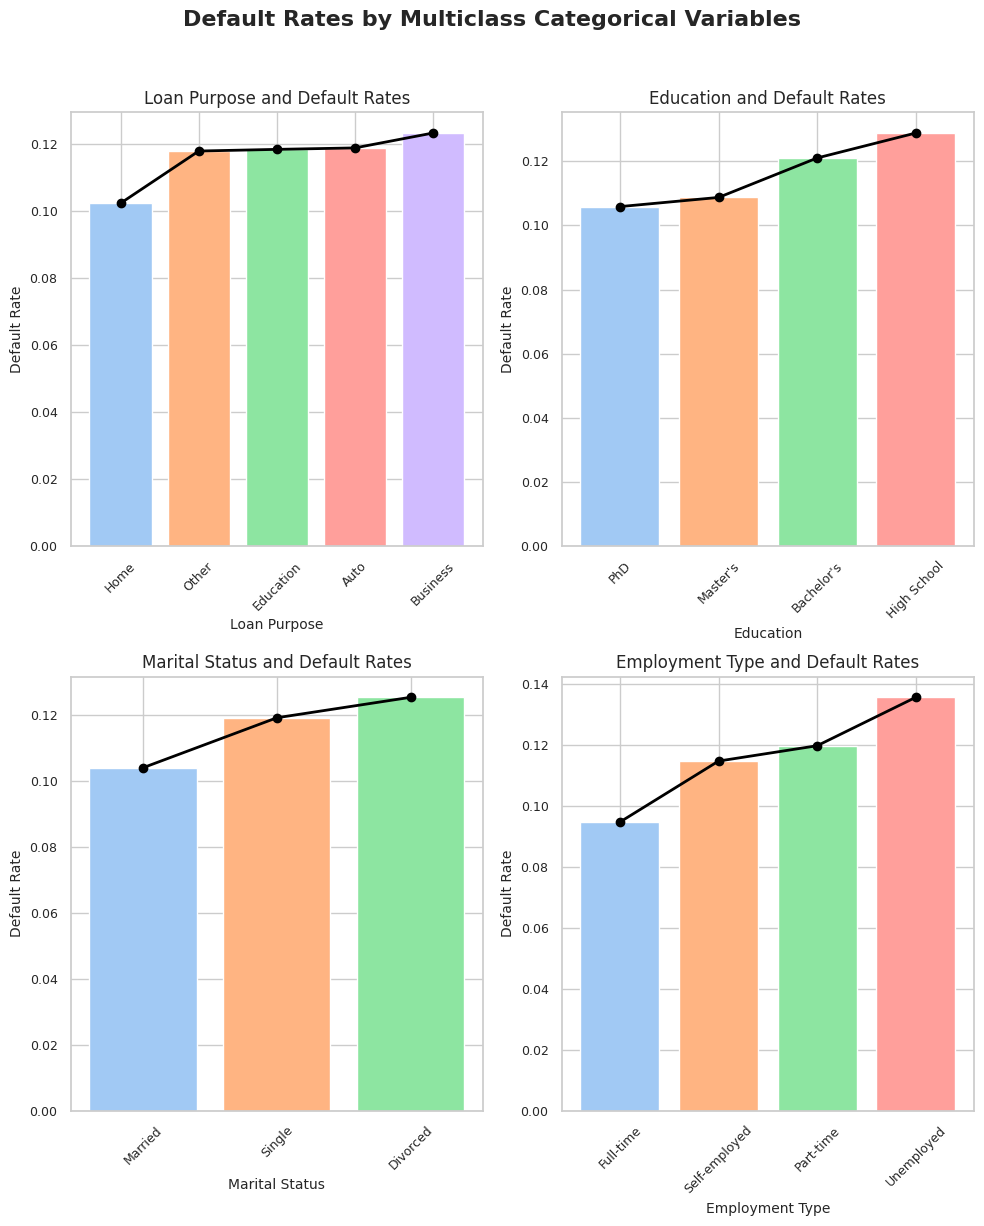

In [ ]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(10, 12))
fig.suptitle("Default Rates by Multiclass Categorical Variables", fontsize=16, fontweight='bold', y=1.02)

# function to plot combo chart
def plot_bar_line(ax, series, title, xlabel):
    categories = series.index
    values = series.values
    ax.bar(categories, values, color=sns.color_palette('pastel'))  # bar chart
    ax.plot(categories, values, color='black', marker='o', linewidth=2)  # line chart

    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Default Rate', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

# Plot 1: Loan Purpose
loan_purpose_avg = df_defaults.groupby("LoanPurpose")["Default"].mean().sort_values()
plot_bar_line(axes[0, 0], loan_purpose_avg, "Loan Purpose and Default Rates", "Loan Purpose")

# Plot 2: Education
education_avg = df_defaults.groupby("Education")["Default"].mean().sort_values()
plot_bar_line(axes[0, 1], education_avg, "Education and Default Rates", "Education")

# Plot 3: Marital Status
marital_status_avg = df_defaults.groupby("MaritalStatus")["Default"].mean().sort_values()
plot_bar_line(axes[1, 0], marital_status_avg, "Marital Status and Default Rates", "Marital Status")

# Plot 4: Employment Type
employment_type_avg = df_defaults.groupby("EmploymentType")["Default"].mean().sort_values()
plot_bar_line(axes[1, 1], employment_type_avg, "Employment Type and Default Rates", "Employment Type")

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()

From these findings, we wanted to further examine how `Education` and `EmploymentStatus` combine in relation to default risk by creating a cross-tabulation matrix. We found that borrowers with the lowest level of employment (Unemployed) and education (High School) had the highest default rates, which may further suggest the greater risk factor of lower education and employment. Conversely, Full-time employees (highest employment level) that either had a Master's or PhD (highest education levels) had the lowest default rates.

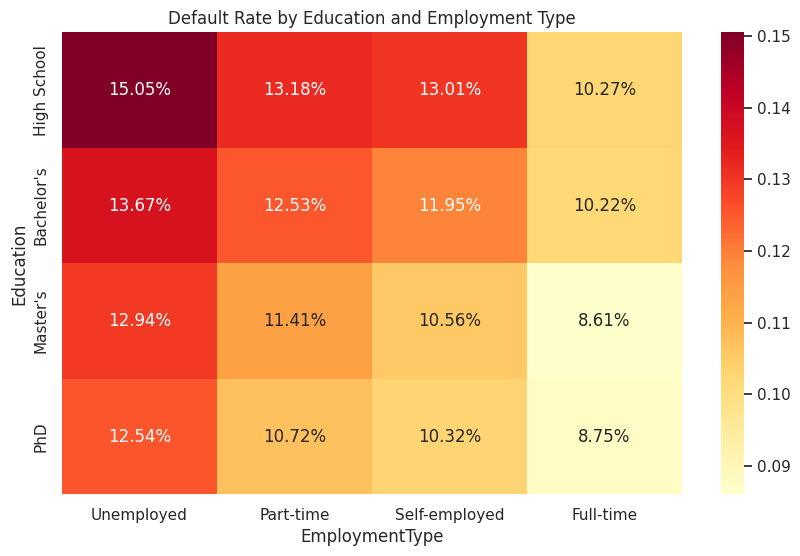

In [ ]:
cross_tab = pd.crosstab(index=df_defaults['Education'], columns=df_defaults['EmploymentType'], values=df_defaults['Default'], aggfunc='mean')
education_order = ['High School', 'Bachelor\'s', 'Master\'s', 'PhD']
employment_order = ['Unemployed', 'Part-time', 'Self-employed', 'Full-time']
cross_tab = cross_tab.reindex(education_order)
cross_tab = cross_tab.reindex(employment_order, axis=1)


plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab, annot=True, fmt=".2%", cmap='YlOrRd')
plt.title('Default Rate by Education and Employment Type')
plt.show()

Finally, we created a kernel density plot to examine in a continuous distribution how the `Age` of a borrower related to `Default` rates. The distribution of loans that defaulted had a strong skew towards younger borrower ages (20-30 year olds), while the loans that did not default had a slight skew towards older ages (40-70 year olds).

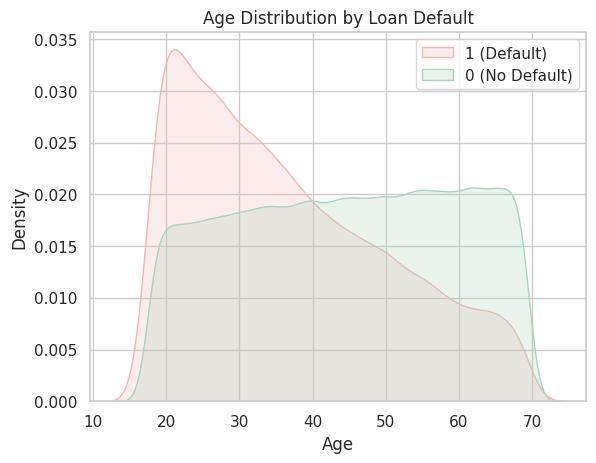

In [ ]:
noDefault_green = "#A8D5BA"
default_red = "#F4B6B0"

sns.kdeplot(df_defaults[df_defaults["Default"] == 1]["Age"], label="1 (Default)", fill=True, color=default_red)
sns.kdeplot(df_defaults[df_defaults["Default"] == 0]["Age"], label="0 (No Default)", fill=True, color=noDefault_green)

plt.title('Age Distribution by Loan Default')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

## IV. Feature Engineering

Based on insights from EDA, we transform and preprocess our data to improve model performance. This includes encoding categorical variables, creating new engineered features, splitting our data into train and test sets.

In [ ]:
# Create a copy so that we don't mess up with the original data for EDA:
df_clean = df_defaults.copy()

In [ ]:
# Drop Loan ID:
df_clean.drop('LoanID', axis=1, inplace=True)

In [ ]:
# Ordinal Encoding on Education and Employment because they have a clear rank:
education_ranking = {"High School": 0,
                     "Bachelor's": 1,
                     "Master's": 2,
                     "PhD": 3}

employment_ranking = {"Unemployed": 0,
                      "Part-time": 1,
                      "Self-employed": 2,
                      "Full-time": 3}

df_clean['Education'] = df_clean['Education'].map(education_ranking)
df_clean['EmploymentType'] = df_clean['EmploymentType'].map(employment_ranking)

In [ ]:
# One-hot Encoding for all other features since they are just labels and no clear rank:
df_clean = pd.get_dummies(df_clean,
                          columns=['MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner'],
                          dtype=int)

In [ ]:
# Create new features:
df_clean['EmploymentStability'] = df_clean['MonthsEmployed'] / df_clean['Age']
df_clean['LoanPerIncome'] = df_clean['LoanAmount'] / df_clean['Income']

In [ ]:
# Standard train test split with 80% training set and 20% test set:
df_final = df_clean.copy()
X = df_final.drop('Default', axis=1)
y = df_final['Default']

# Use stratify=y to ensure the same class ratio in train & test set:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Number of observations for the training set: {X_train.shape[0]}")
print(f"Number of observations for the test set: {X_test.shape[0]}")

Number of observations for the training set: 204277
Number of observations for the test set: 51070


To address class imbalance during data splitting, we implemented the `stratify=y `argument in `train_test_split()`. This ensures that both the training and test sets maintain the original class distribution, allowing the model to learn from and be evaluated on data with consistent class proportions. As a result, performance metrics such as recall, precision, and ROC AUC become more meaningful and reliable.

We also observed slight improvements in model performance after applying stratification. For instance, the default logistic regression model’s ROC AUC score increased from 0.7186 to 0.7311. Other models showed similar incremental gains. While the improvements are modest, they are still significant

## V. Modeling

We first establish a Logistic Regression model as a baseline. Given the imbalanced nature of the dataset (with significantly more non-defaults than defaults), we also focus on ensemble tree-based models that are more robust to imbalance: Random Forest and XGBoost.

For each model, we applied GridSearchCV to optimize key hyperparameters for each model, using ROC AUC as the scoring metric. This choice is ideal for imbalanced datasets, as ROC AUC is not biased by class distribution.

Throughout model development, we use metrics such as ROC AUC, F1-score, precision, recall, and confusion matrix, which are better suited for imbalanced classification problems than accuracy alone.

In the context of predicting loan defaults:

* **ROC AUC** reflects the model’s ability to distinguish between defaulters and non-defaulters.

* **Precision** indicates the proportion of predicted defaults that were truly defaults.

* **Recall** shows the proportion of actual defaults the model successfully identified, which is especially critical since missing a default can be costly.

* **F1-score** provides a balanced measure of precision and recall, helping evaluate overall effectiveness in capturing defaulters without too many false alarms.





Here are the Python packages we will use for this modeling section. Most of the tools we will use come from Scikit-Learn, a powerful ML library tailored to all kinds of simple and complicated modeling tasks.

In [ ]:
# Import needed packages for each modeling task:
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.utils import class_weight
import xgboost as xgb
from xgboost import XGBClassifier

# Other useful packages:
import statsmodels.api as sm
from scipy.stats import ttest_ind
import time
from IPython.display import display

### **1. Benchmark: Logistic Regression**

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. It predicts whether something belongs to one of two classes. In our case, whether a loan will "default" or "non-default". Logistic Regression predicts the probability of a class label using the logistic (sigmoid) function, which outputs values between 0 and 1.

We are choosing Logistic Regression as our baseline model because it is straightforward to understand and interpret, efficient on large datasets, and suitable for binary classification.

In this section, we build and evaluate four different logistic regression models to identify the most effective and efficient configuration. We start with a baseline model using default parameters, progressively experiment with class balancing and hyperparameter tuning, and finally select a model that offers strong predictive performance while minimizing computational cost.

#### Logistic Regression with Default Parameters

First, we started with Logistic Regression using default settings to establish a baseline. While it achieved high overall accuracy, it performed poorly on the minority (default) class, highlighting the impact of class imbalance.

In [ ]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

logreg_accuracy = accuracy_score(y_test, y_pred)
logreg_roc_auc = roc_auc_score(y_test, y_pred_prob)
logreg_precision = precision_score(y_test, y_pred)
logreg_recall = recall_score(y_test, y_pred)
logreg_f1 = f1_score(y_test, y_pred)
logreg_cm = confusion_matrix(y_test, y_pred)

print("Logistic Regression with Default Parameters Metrics:")
print(f"Accuracy Score : {logreg_accuracy:.4f}")
print(f"ROC AUC Score : {logreg_roc_auc:.4f}")
print(f"Precision     : {logreg_precision:.4f}")
print(f"Recall        : {logreg_recall:.4f}")
print(f"F1-Score      : {logreg_f1:.4f}")
print("\nConfusion Matrix:")
print(logreg_cm)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression with Default Parameters Metrics:
Accuracy Score : 0.8843
ROC AUC Score : 0.7311
Precision     : 0.5743
Recall        : 0.0143
F1-Score      : 0.0280

Confusion Matrix:
[[45076    63]
 [ 5846    85]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.57      0.01      0.03      5931

    accuracy                           0.88     51070
   macro avg       0.73      0.51      0.48     51070
weighted avg       0.85      0.88      0.83     51070



This evaluation metrics of the model model shows that it not useful for default detection. It’s only accurate because it always predicts “no default.” Accuracy is misleading due to heavy class imbalance. Recall = 0.0143 which indicates that model barely detects any defaults.F1-Score is nearly 0, which means it has very poor performance on minority class. ROC AUC (0.7311) shows that ranking of predictions is decent, but thresholding is ineffective.

It is not suitable for imbalanced data where catching defaults is important.



#### Logistic Regression with balanced class

To improve the logistic regression model, we introduced `class_weight='balanced'` to address the severe class imbalance. This adjustment significantly boosted recall and F1-score for the default class, highlighting the critical importance of handling class imbalance during model training.

In [ ]:
logreg_balanced = LogisticRegression(class_weight = "balanced")
logreg_balanced.fit(X_train, y_train)

y_pred = logreg_balanced.predict(X_test)
y_pred_prob = logreg_balanced.predict_proba(X_test)[:, 1]

logreg_balanced_accuracy = accuracy_score(y_test, y_pred)
logreg_balanced_accuracy

logreg_balanced_accuracy = accuracy_score(y_test, y_pred)
logreg_balanced_roc_auc = roc_auc_score(y_test, y_pred_prob)
logreg_balanced_precision = precision_score(y_test, y_pred)
logreg_balanced_recall = recall_score(y_test, y_pred)
logreg_balanced_f1 = f1_score(y_test, y_pred)
logreg_balanced_cm = confusion_matrix(y_test, y_pred)

print("Logistic Regression with Balanced Class Evaluation Metrics:")
print(f"Accuracy Score : {logreg_balanced_accuracy:.4f}")
print(f"ROC AUC Score : {logreg_balanced_roc_auc:.4f}")
print(f"Precision     : {logreg_balanced_precision:.4f}")
print(f"Recall        : {logreg_balanced_recall:.4f}")
print(f"F1-Score      : {logreg_balanced_f1:.4f}")
print("\nConfusion Matrix:")
print(logreg_balanced_cm)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression with Balanced Class Evaluation Metrics:
Accuracy Score : 0.6777
ROC AUC Score : 0.7297
Precision     : 0.2132
Recall        : 0.6596
F1-Score      : 0.3222

Confusion Matrix:
[[30700 14439]
 [ 2019  3912]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.68      0.79     45139
           1       0.21      0.66      0.32      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.67      0.56     51070
weighted avg       0.85      0.68      0.73     51070



This model sacrifices accuracy to dramatically improve recall and F1-score for the minority class (defaults). It captures far more defaults than the default logistic regression model. This result indicates that we should use `class_weight = 'balanced'`.

#### Logistic Regression with Hyperparameter Tuning

This section conducts an extensive GridSearchCV across multiple parameters (C, penalty, max_iter, and k for feature selection) to explore combinations that might improve performance, particularly on the minority class.

* `C` controls the strength of the regularization. A small C (e.g., 0.1) penalizes large coefficients more heavily, helping prevent overfitting but might underfit if too small. A larger C (e.g., 1 or above) allows the model more flexibility, potentially improving training accuracy but increasing the risk of overfitting.

* `penalty `specifies the norm used in the penalization—either 'l1' (Lasso) or 'l2' (Ridge). One can also try elasticNet here, but since our features are not correlated, we have decided to try only l1 and l2. l1 encourages sparsity, meaning it can zero out irrelevant features. l1 acts as feature selection. l2 shrinks coefficients but rarely zeros them, helping with multicollinearity. l1 is helpful when we suspect many features are irrelevant, while l2 is more stable when most features contribute.

* `max_iter` sets the maximum number of iterations for the solver to converge. This is important because convergence can take longer with l1 or imbalanced data. raisting the max_iter value helps to avoid premature stopping and ensures convergence of solver.


* `k` determines how many features are kept after univariate statistical tests. Lower k focuses on the most informaative features, reduces overfitting and speeds up trainnig. Higher k includes more features, and perhaps can capture more nuanced patterns but risks overfitting. Finding the right k improves model interpretability and efficidency without sacrificng predictive power.
  

We decided to use the 'saga' solver as it efficiently handles large datasets and supports both L1 and L2 penalties. Based on earlier results, incorporating `class_weight='balanced'` clearly improves the model’s ability to detect defaults, making it a crucial setting in our hyperparameter tuning process.

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif)),
    ('clf', LogisticRegression(class_weight='balanced', solver='saga')) #uses saga because datset is large. supports both l1 and l2 penalties
])

param_grid = {
    'select__k': [10, 15, 'all'],  # # of top features to select
    'clf__penalty': ['l1', 'l2'],  # regularization penalties
    'clf__C': [0.01, 0.1, 1, 10], # regularization strength
    'clf__max_iter': [500, 1000]  # max iterations for convergence
}

start_time = time.time()

logreg_grid = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='roc_auc', verbose=1, n_jobs=-1)
logreg_grid.fit(X_train, y_train)

end_time = time.time()
runtime = end_time - start_time
print(f"\n Model training and tuning completed in {runtime:.2f} seconds")

print("Best parameters from GridSearch:")
print(logreg_grid.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits

 Model training and tuning completed in 634.46 seconds
Best parameters from GridSearch:
{'clf__C': 0.01, 'clf__max_iter': 1000, 'clf__penalty': 'l1', 'select__k': 'all'}


In [ ]:
logreg_best_model = logreg_grid.best_estimator_
y_pred = logreg_best_model.predict(X_test)
y_pred_prob = logreg_best_model.predict_proba(X_test)[:, 1]

logreg_grid_accuracy = accuracy_score(y_test, y_pred)
logreg_grid_roc_auc = roc_auc_score(y_test, y_pred_prob)
logreg_grid_precision = precision_score(y_test, y_pred)
logreg_grid_recall = recall_score(y_test, y_pred)
logreg_grid_f1 = f1_score(y_test, y_pred)
logreg_grid_cm = confusion_matrix(y_test, y_pred)

print("Logistic Regression with Hyperparameter Tuning Evaluation Metrics:")
print(f"Accuracy Score : {logreg_grid_accuracy:.4f}")
print(f"ROC AUC Score : {logreg_grid_roc_auc:.4f}")
print(f"Precision     : {logreg_grid_precision:.4f}")
print(f"Recall        : {logreg_grid_recall:.4f}")
print(f"F1-Score      : {logreg_grid_f1:.4f}")
print("\nConfusion Matrix:")
print(logreg_grid_cm)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression with Hyperparameter Tuning Evaluation Metrics:
Accuracy Score : 0.6903
ROC AUC Score : 0.7617
Precision     : 0.2279
Recall        : 0.6979
F1-Score      : 0.3436

Confusion Matrix:
[[31115 14024]
 [ 1792  4139]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.69      0.80     45139
           1       0.23      0.70      0.34      5931

    accuracy                           0.69     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.69      0.74     51070



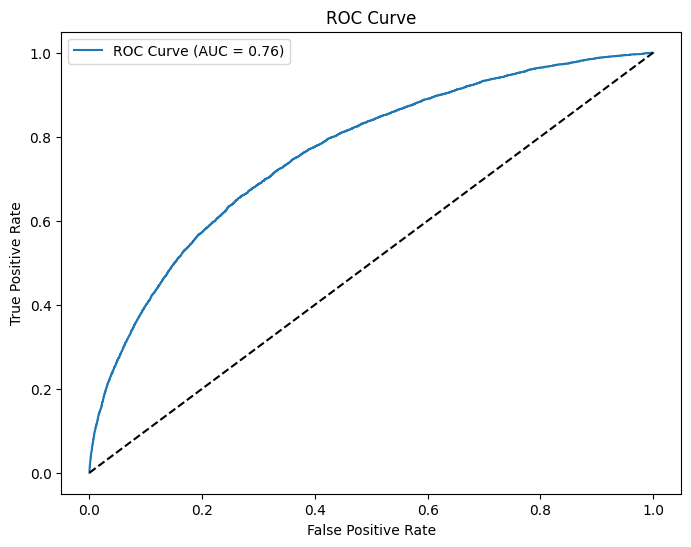

In [ ]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_pred_prob):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

There is a good trade-off between recall and precision. This model has high ROC AUC, indicating overall better separation between classes. There is a slight drop in accuracy. However, it is acceptable given the improvement in F1.

#### Checking statistical significance of different parameters using Statsmodel

Due to the long run times from the initial GridSearch, we applied t-tests using statsmodels to compare predicted probabilities from different parameter combinations. This helped assess whether performance differences were statistically significant — and whether more extensive tuning was worth the computational cost.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# base configuration using the best params from above {'clf__C': 0.01, 'clf__max_iter': 1000, 'clf__penalty': 'l1', 'select__k': 'all'}
base_config = {
    'select__k': 'all',
    'clf__penalty': 'l1',
    'clf__C': 0.01,
    'clf__max_iter': 500
}


##### Collect p-values from different configurations of C

In [ ]:
pvals_dict = {}
for C_val in [0.01, 0.1, 1]:
    pipeline = Pipeline([
        ('select', SelectKBest(score_func = f_classif, k = "all")),
        ('clf', LogisticRegression(penalty=base_config['clf__penalty'],
                             solver='saga',
                             C=C_val,
                             class_weight='balanced',
                             max_iter=base_config['clf__max_iter']))
    ])

    pipeline.fit(X_train_scaled, y_train)
    preds = pipeline.predict_proba(X_train_scaled)[:, 1]

    # Save predictions for statistical test
    pvals_dict[f'C={C_val}'] = preds

# Compare configurations of C using t-tests
print("\nT-tests between different C values (holding other parameters fixed):")
keys = list(pvals_dict.keys())
for i in range(len(keys)):
    for j in range(i+1, len(keys)):
        stat, pval = ttest_ind(pvals_dict[keys[i]], pvals_dict[keys[j]])
        print(f"{keys[i]} vs {keys[j]}: p-value = {pval:.4f}")


T-tests between different C values (holding other parameters fixed):
C=0.01 vs C=0.1: p-value = 0.5089
C=0.01 vs C=1: p-value = 0.4631
C=0.1 vs C=1: p-value = 0.9416


All p-values are > 0.05. No statistical significant difference. Model is not sensitive to the choice of C within this range.

##### Collect p-values from different configurations of k (number of top features)

In [ ]:
pvals_dict = {}
for k in [5, 7, 10, 13, 15, 17, 'all']:
    pipeline = Pipeline([
        ('select', SelectKBest(score_func = f_classif, k = k)),
        ('clf', LogisticRegression(penalty=base_config['clf__penalty'],
                             solver='saga',
                             C=base_config['clf__C'],
                             class_weight='balanced',
                             max_iter=base_config['clf__max_iter']))
    ])

    pipeline.fit(X_train_scaled, y_train)
    preds = pipeline.predict_proba(X_train_scaled)[:, 1]

    # Save predictions for statistical test
    pvals_dict[f'k={k}'] = preds

# Compare configurations of number of top features to use using t-tests
print("\nT-tests between different k values (holding other parameters fixed):")
keys = list(pvals_dict.keys())
for i in range(len(keys)):
    for j in range(i+1, len(keys)):
        stat, pval = ttest_ind(pvals_dict[keys[i]], pvals_dict[keys[j]])
        print(f"{keys[i]} vs {keys[j]}: p-value = {pval:.4f}")


T-tests between different k values (holding other parameters fixed):
k=5 vs k=7: p-value = 0.0219
k=5 vs k=10: p-value = 0.0000
k=5 vs k=13: p-value = 0.0000
k=5 vs k=15: p-value = 0.0000
k=5 vs k=17: p-value = 0.0000
k=5 vs k=all: p-value = 0.0000
k=7 vs k=10: p-value = 0.0004
k=7 vs k=13: p-value = 0.0000
k=7 vs k=15: p-value = 0.0000
k=7 vs k=17: p-value = 0.0000
k=7 vs k=all: p-value = 0.0000
k=10 vs k=13: p-value = 0.0066
k=10 vs k=15: p-value = 0.0000
k=10 vs k=17: p-value = 0.0000
k=10 vs k=all: p-value = 0.0000
k=13 vs k=15: p-value = 0.0738
k=13 vs k=17: p-value = 0.0150
k=13 vs k=all: p-value = 0.0002
k=15 vs k=17: p-value = 0.5184
k=15 vs k=all: p-value = 0.0575
k=17 vs k=all: p-value = 0.2100


Setting the p-values as 0.05. There is significnat differences between k = 5 vs everthing else, k=7 vs everything else, k=10 vs the higher k values, and k=13 vs the higher k values. This suggests that lower k values produces statistically different prediction behavior from higher values. Thus, to balance model diversity and computational cost, we can try  'select__k': [10, 15]

##### Collect p-values from different configurations of penalty

In [ ]:
pvals_dict = {}
for p in ['l1','l2']:
    pipeline = Pipeline([
        ('select', SelectKBest(score_func = f_classif, k = "all")),
        ('clf', LogisticRegression(penalty=p,
                             solver='saga',
                             C=base_config['clf__C'],
                             class_weight='balanced',
                             max_iter=base_config['clf__max_iter']))
    ])

    pipeline.fit(X_train_scaled, y_train)
    preds = pipeline.predict_proba(X_train_scaled)[:, 1]

    # Save predictions for statistical test
    pvals_dict[f'penalty={p}'] = preds

# Compare configurations of penalty using t-tests
print("\nT-test between different penalty values (holding other parameters fixed):")
keys = list(pvals_dict.keys())
for i in range(len(keys)):
    for j in range(i+1, len(keys)):
        stat, pval = ttest_ind(pvals_dict[keys[i]], pvals_dict[keys[j]])
        print(f"{keys[i]} vs {keys[j]}: p-value = {pval:.4f}")


T-test between different penalty values (holding other parameters fixed):
penalty=l1 vs penalty=l2: p-value = 0.6157


p-value > 0.05. Not statistically significant. can pick just one, unless we are particularly interested in feature sparsity beneift of l1.

##### Collect p-values from different configurations of penalty

In [ ]:
pvals_dict = {}
for iteration in [500,1000]:
    pipeline = Pipeline([
        ('select', SelectKBest(score_func = f_classif, k = "all")),
        ('clf', LogisticRegression(penalty=base_config['clf__penalty'],
                             solver='saga',
                             C=base_config['clf__C'],
                             class_weight='balanced',
                             max_iter=iteration))
    ])

    pipeline.fit(X_train_scaled, y_train)
    preds = pipeline.predict_proba(X_train_scaled)[:, 1]

    # Save predictions for statistical test
    pvals_dict[f'max_iter={iteration}'] = preds


# Compare configurations of max_iter  using t-tests
print("\nT-tests between different penalty values (holding other parameters fixed):")
keys = list(pvals_dict.keys())
for i in range(len(keys)):
    for j in range(i+1, len(keys)):
        stat, pval = ttest_ind(pvals_dict[keys[i]], pvals_dict[keys[j]])
        print(f"{keys[i]} vs {keys[j]}: p-value = {pval:.4f}")


T-tests between different penalty values (holding other parameters fixed):
max_iter=500 vs max_iter=1000: p-value = 0.9948


P-value being close to 1 means the two models with different max_iter have nearly identical results. We can stick to max_iter = 500

#### Logistic Regression with Modified Hyperparameter Tuning

Based on t-test results, selected a reduced hyperparameter grid that offered similar performance with drastically reduced run time, achieving a balanced trade-off between efficiency and effectiveness.

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif)),
    ('clf', LogisticRegression(class_weight='balanced', solver='saga')) #uses saga because datset is large. supports both l1 and l2 penalties
])

modified_param_grid = {
    'select__k': [10, 15],  # # of top features to select
    'clf__penalty': ['l1', 'l2'],  # regularization penalties
    'clf__C': [0.1, 1], # regularization strength
    'clf__max_iter': [500]  # max iterations for convergence
}

start_time = time.time()

logreg_grid = GridSearchCV(estimator=pipeline, param_grid=modified_param_grid, cv=5, scoring='roc_auc', verbose=1, n_jobs=-1)
logreg_grid.fit(X_train, y_train)

end_time = time.time()
runtime = end_time - start_time
print(f"\n Model training and tuning completed in {runtime:.2f} seconds")

print("Best parameters from GridSearch:")
print(logreg_grid.best_params_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Model training and tuning completed in 87.05 seconds
Best parameters from GridSearch:
{'clf__C': 0.1, 'clf__max_iter': 500, 'clf__penalty': 'l1', 'select__k': 15}


In [ ]:
logreg_best_model = logreg_grid.best_estimator_
y_pred = logreg_best_model.predict(X_test)
y_pred_prob = logreg_best_model.predict_proba(X_test)[:, 1]

logreg_grid_accuracy = accuracy_score(y_test, y_pred)
logreg_grid_roc_auc = roc_auc_score(y_test, y_pred_prob)
logreg_grid_precision = precision_score(y_test, y_pred)
logreg_grid_recall = recall_score(y_test, y_pred)
logreg_grid_f1 = f1_score(y_test, y_pred)
logreg_grid_cm = confusion_matrix(y_test, y_pred)

print("Logistic Regression with Modified Hyperparameter Tuning Evaluation Metrics:")
print(f"Accuracy Score : {logreg_grid_accuracy:.4f}")
print(f"ROC AUC Score : {logreg_grid_roc_auc:.4f}")
print(f"Precision     : {logreg_grid_precision:.4f}")
print(f"Recall        : {logreg_grid_recall:.4f}")
print(f"F1-Score      : {logreg_grid_f1:.4f}")
print("\nConfusion Matrix:")
print(logreg_grid_cm)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression with Modified Hyperparameter Tuning Evaluation Metrics:
Accuracy Score : 0.6896
ROC AUC Score : 0.7599
Precision     : 0.2274
Recall        : 0.6975
F1-Score      : 0.3430

Confusion Matrix:
[[31082 14057]
 [ 1794  4137]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.69      0.80     45139
           1       0.23      0.70      0.34      5931

    accuracy                           0.69     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.69      0.74     51070



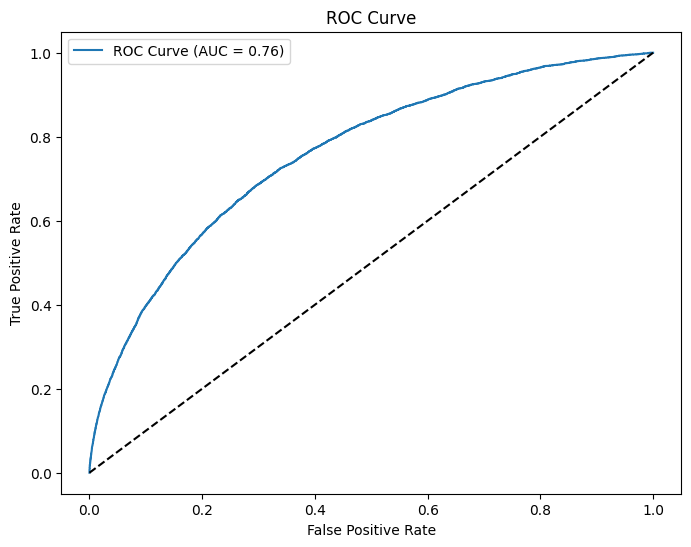

In [ ]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_pred_prob):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

This model has almost identical performance to full tuning. The Runtime reduced from 634 seconds to 87 seconds, with minimal performance loss.

**Conclusion**

The T-test-guided hyperparameter-tuned model is the most recommended as our baseline model.

The model's runtime improved by approximately 86.2%.

It has great recall and F1 compared to others. The model is  time-efficient for retraining or revalidating and it balances predictive power with interpretability and practical training cost.

#### Model Interpretation  and the Top Three Features

Age (-0.5905): Older individuals are  less likely to default. This may indicate experience, financial stability, or risk aversion.

LoanPerIncome (0.4706): Higher loan-to-income ratios are strongly associated with increased default risk. This is quite intuitive as a high debt burden increases financial stress.

InterestRate (0.4656): Higher interest rates are associated with higher default risk. This is possibly because higher rates go to riskier borrowers or are harder to repay.

In [ ]:
feature_names = X_train.columns

scaler = logreg_best_model.named_steps['scaler']
selector = logreg_best_model.named_steps['select']
clf = logreg_best_model.named_steps['clf']

selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = feature_names[selected_feature_indices]

coefficients = clf.coef_[0]  # get coefficients

feature_coef = list(zip(selected_feature_names, coefficients)) # Combine names and coefficients

feature_coef_sorted = sorted(feature_coef, key=lambda x: abs(x[1]), reverse=True)

print("\nTop Features and Coefficients (sorted by importance):")
for name, coef in feature_coef_sorted:
    print(f"{name}: {coef:.4f}")




Top Features and Coefficients (sorted by importance):
Age: -0.5905
LoanPerIncome: 0.4706
InterestRate: 0.4656
MonthsEmployed: -0.3398
EmploymentType: -0.1467
CreditScore: -0.1247
NumCreditLines: 0.1051
Education: -0.1020
MaritalStatus_Married: -0.0834
HasCoSigner_Yes: -0.0660
HasCoSigner_No: 0.0660
HasDependents_No: 0.0640
HasDependents_Yes: -0.0640
Income: 0.0191
LoanAmount: 0.0033


### **2. Tree Model Option 1: Random Forest (Bagging)**

##### **What is Random Forest?**

We now have our benchmark model, the Logistic Regression model results. Next, we will seek to improve the model performance that gives more correct predictions on our test set.

First, we will utilize the Random Forest model. Random Forest is a strong ML algorithm that makes predictions based on multiple independent decision trees, each with a subset of variables from the dataset. This is a classical ensemble learning method called "bagging" (boostrap aggregating).

##### **Why Random Forest is a Good Choice for Loan Default Prediction?**

- **Handles both numerical and categorical data**  
Perfect for real-world datasets with mixed feature types (e.g. income, mortgage status, etc).
- **Performs well with imbalanced datasets**  
  Loan default datasets usually have more “non-default” cases; Random Forest + ROC AUC scoring handles this better than accuracy.
- **Reduces overfitting via bagging**  
  Uses bootstrap sampling and feature randomness to create diverse trees and prevent overfitting.
- **Provides feature importance**  
  Helps identify which features are most predictive (e.g. loan amount, income, interest rate, etc.).
- **Captures non-linear relationships**  
Default behavior is complex — Random Forest is effective at capturing interactions and non-linear patterns between features.
- **Robust to outliers and noise**  
Decision trees are not affected much by extreme values in features like income or loan amount.

#### **Random Forest Classifier - Initial Model**
#### **Purpose:**
- To establish a **baseline model** for predicting loan defaults using a Random Forest classifier.
- Evaluate the model's ability to distinguish between **defaulters** and **non-defaulters**.
- Identify performance gaps, especially due to potential **class imbalance**.

In [ ]:
# Initialize and train Random Forest:
rf_model = RandomForestClassifier(n_estimators=100, random_state = 42)
rf_model.fit(X_train, y_train)

# Predict on the test set:
y_pred = rf_model.predict(X_test)

# Evaluation:
print("Classification Report:")
print(classification_report(y_test, y_pred))


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy Score:")
print(f"{accuracy_score(y_test, y_pred):4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.61      0.05      0.09      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.51     51070
weighted avg       0.86      0.89      0.84     51070

Confusion Matrix:
[[44950   189]
 [ 5640   291]]
Accuracy Score:
0.885863


####  **Key Observations:**
-	The high precision, recall and f-1 score for non-defaulters (Class 0) indicated that the model performs very well on the majority class.
-	Likewise, low recall for the defaulters (Class1) indicates that the model struggles to detect defaulters, meaning most actual defaulters are missed.
-	High accuracy is misleading due to **severe class imbalance**. Model is biased towards predicting non-defaulters (majority class).
#### Confusion Matrix:
-	Out of 5,900 actual defaulters, only 291 were correctly identified and 5,640 defaulters were identified as non-defaulters.
#### **Next Step:**
-	The next step is to perform **hyperparameter tuning** to optimize the performance of the Random Forest model.
-	The default settings of the model may not be ideal for this dataset, especially given the **class imbalance** and **complexity** of the loan default patterns.
-	Hyperparameter tuning allows us to **reduce overfitting or underfitting** potentially improving recall for the minority class (defaulters) without sacrificing overall performance.


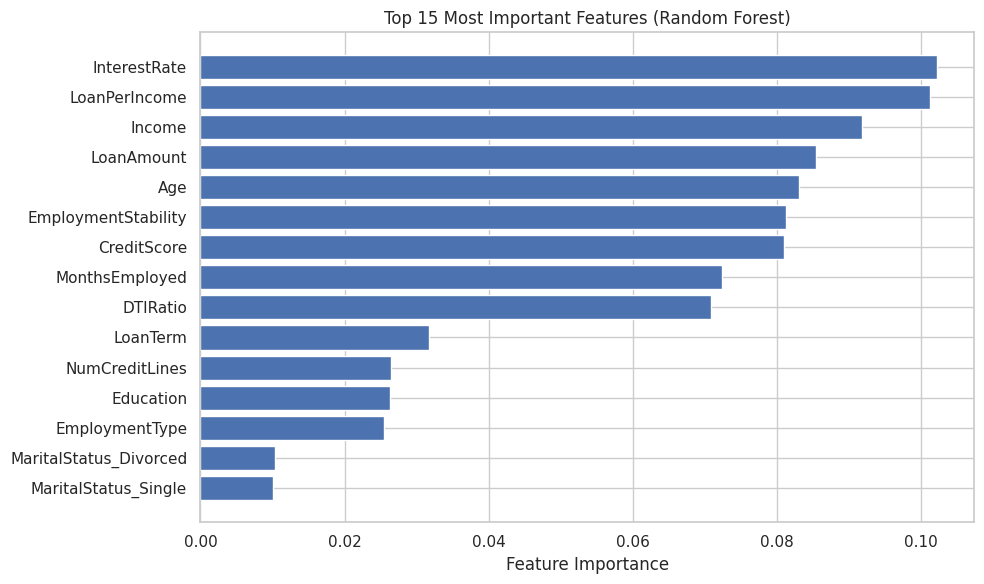

In [ ]:
# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot top 15 features:
plt.figure(figsize=(10,6))

plt.barh(feat_imp_df['Feature'] [:15], feat_imp_df['Importance'][:15])

plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

####  **Feature Importance Key Observations:**
-	InterestRate is the most important feature, suggesting the ratio of loan amount to income is highly predictive of default risk.
-	The other key features are LoanPerIncome, Income that highlight the borrower’s financial burden and ability to repay.
-	These top features could get reshuffled after the hyperparameter tuning.

#### **Random Forest Hyperparameter Tuning with Grid Search**
#####**Purpose:**
-	To improve model performance by finding the **optimal set of hyperparameters**
-	To enhance model’s ability to distinguish between defaulters and non-defaulters, especially given class imbalance.

#####**Approach:**
-	Used ‘GridSearchCV’ with 3-fold cross-validation on a **30% subset of training** (to reduce computation time yet getting satisfying results).
-	Tuned key parameters: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_features`.

In [ ]:
# Sample a subset of training data to speed up grid search:
X_sample = X_train.sample(frac=0.3, random_state=42)  # 30% sample
y_sample = y_train.loc[X_sample.index]

# Define the hyperparameter grid:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

# Initialize the model:
rf = RandomForestClassifier(random_state=42)

# Grid search:
rf_grid = GridSearchCV(estimator=rf,
                       param_grid=param_grid,
                       cv=3,
                       verbose=1,
                       n_jobs=-1,
                       scoring='roc_auc')

# Start timer:
start_time = time.time()

# Fit on sampled training data:
rf_grid.fit(X_sample, y_sample)

# End timer:
end_time = time.time()
print(f"Grid Search Tuning took {end_time - start_time:.2f} seconds.")

# Best model from grid search:
best_rf = rf_grid.best_estimator_

print("Best Parameters:")
print(rf_grid.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Grid Search Tuning took 572.16 seconds.
Best Parameters:
{'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


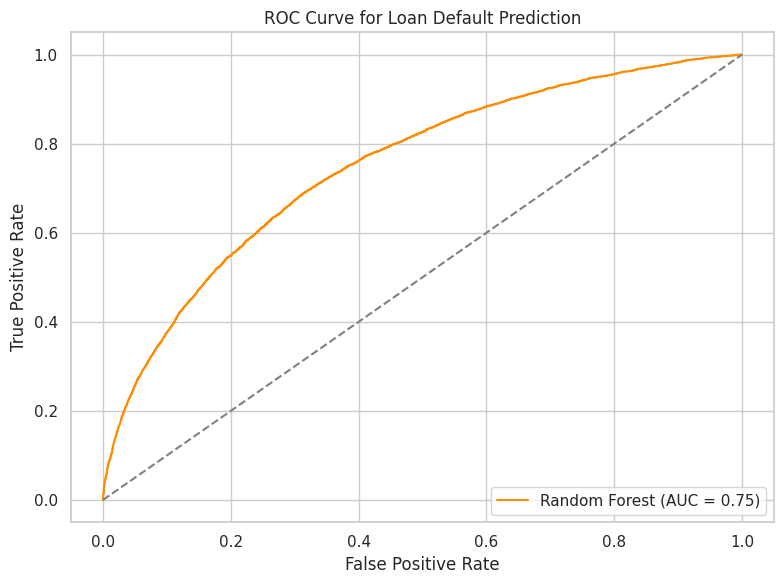

In [ ]:
# Predict probabilities
y_probs = best_rf.predict_proba(X_test)[:,1] #probabilities for class 1

# ROC curve
fpr, tpr, threshholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize = (8,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  #random chance line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Loan Default Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

####**Observations:**
-	The AUC (Area Under Curve) for the tuned Random Forest Mode is 0.75, indicating a moderate ability to separate the two classes.

####**Conclusion:**
-	The model has room for improvement and adjusting the decision threshold may further help in identifying more defaulters effectively.


#### **Retraining full training set using tuned parameters**

In [ ]:
# Train model
def train_best_rf(X_train, y_train):
    best_rf = RandomForestClassifier(
        bootstrap=True,
        max_depth=10,
        max_features='sqrt',
        min_samples_leaf=2,
        min_samples_split=2,
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    best_rf.fit(X_train, y_train)
    return best_rf

# List for storing the results
results = []

# Function to collect metrics; includes overall & per-class details.
def collect_metrics(y_true, y_probs, threshold, dataset_name):
    # Generate predictions based on the given threshold
    preds = (y_probs >= threshold).astype(int)

    # Get overall metrics (for the aggregated predictions)
    overall_accuracy = accuracy_score(y_true, preds)
    overall_precision = precision_score(y_true, preds, zero_division=0)
    overall_recall = recall_score(y_true, preds, zero_division=0)
    overall_f1 = f1_score(y_true, preds, zero_division=0)
    overall_roc_auc = roc_auc_score(y_true, y_probs)

    # Get the full classification report as a dictionary to extract per-class values.
    rep = classification_report(y_true, preds, output_dict=True, zero_division=0)

    # Append overall and per-class metrics to the results list.
    results.append({
      'Dataset': dataset_name,
      'Threshold': threshold,
      'Accuracy': round(overall_accuracy, 3),
      'Precision_overall': round(overall_precision, 3),
      'Recall_overall': round(overall_recall, 3),
      'F1_overall': round(overall_f1, 3),
      'ROC AUC': round(overall_roc_auc, 3),
      'Precision_0': round(rep['0']['precision'], 3),
      'Recall_0': round(rep['0']['recall'], 3),
      'F1_0': round(rep['0']['f1-score'], 3),
      'Precision_1': round(rep['1']['precision'], 3),
      'Recall_1': round(rep['1']['recall'], 3),
      'F1_1': round(rep['1']['f1-score'], 3)
  })

# ---- Run the model and collect predictions ----

# Assume X_train, y_train, X_test, and y_test are already defined.
model = train_best_rf(X_train, y_train)

# Get prediction probabilities for the positive class (class 1)
train_probs = model.predict_proba(X_train)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

# Collect metrics using the default threshold (0.5)
collect_metrics(y_train, train_probs, 0.5, 'Train')
collect_metrics(y_test, test_probs, 0.5, 'Test')

# Collect metrics for custom thresholds (sensitivity analysis)
for t in [0.2, 0.3, 0.4]:
    collect_metrics(y_train, train_probs, t, 'Train')
    collect_metrics(y_test, test_probs, t, 'Test')


In [ ]:
# Convert results to DataFrame
metrics_df = pd.DataFrame(results)

# Reorder columns for better readability
cols = [
    'Dataset', 'Threshold', 'Accuracy', 'ROC AUC',
    'Precision_0', 'Recall_0', 'F1_0',
    'Precision_1', 'Recall_1', 'F1_1'
]

metrics_df = metrics_df[cols]  # Reorder columns

# Display it nicely (especially in notebooks)
display(metrics_df)

,Dataset,Threshold,Accuracy,ROC AUC,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1
0,Train,0.5,0.752,0.807,0.949,0.759,0.844,0.274,0.691,0.393
1,Test,0.5,0.735,0.756,0.939,0.749,0.833,0.249,0.632,0.357
2,Train,0.2,0.197,0.807,0.995,0.092,0.168,0.126,0.997,0.224
3,Test,0.2,0.192,0.756,0.982,0.087,0.160,0.124,0.988,0.221
4,Train,0.3,0.390,0.807,0.983,0.316,0.478,0.156,0.960,0.268
5,Test,0.3,0.377,0.756,0.969,0.305,0.464,0.149,0.926,0.257
6,Train,0.4,0.593,0.807,0.968,0.558,0.708,0.203,0.859,0.329
7,Test,0.4,0.578,0.756,0.955,0.548,0.697,0.190,0.804,0.307


In [ ]:
# List of thresholds to evaluate
thresholds = [0.5, 0.2, 0.3, 0.4]

# Loop and print confusion matrices
for threshold in thresholds:
    y_pred_test_custom = (test_probs >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_test_custom)

    # Nicely formatted output
    print(f"\n Confusion Matrix (Test Set) at Threshold = {threshold}")
    cm_df = pd.DataFrame(cm,
                         index=['Actual_0', 'Actual_1'],
                         columns=['Pred_0', 'Pred_1'])
    print(cm_df)


 Confusion Matrix (Test Set) at Threshold = 0.5
          Pred_0  Pred_1
Actual_0   33812   11327
Actual_1    2183    3748

 Confusion Matrix (Test Set) at Threshold = 0.2
          Pred_0  Pred_1
Actual_0    3931   41208
Actual_1      72    5859

 Confusion Matrix (Test Set) at Threshold = 0.3
          Pred_0  Pred_1
Actual_0   13783   31356
Actual_1     438    5493

 Confusion Matrix (Test Set) at Threshold = 0.4
          Pred_0  Pred_1
Actual_0   24752   20387
Actual_1    1161    4770


#### **Threshold Sensitivity Analysis: 0.2 vs 0.3 vs 0.4**

**Threshold = 0.5** (Default)
-	Best balance between precision and recall for class 1.
-	Highest F-1 score for class 1 (0.393 Train / 0.357 Test)
-	Good for overall performance and model stability

**Threshold = 0.2**
-	Maximizes recall for class 1 (0.997 Train / 0.988 Test) – catches almost all defaults.
-	But precision is extremely low (~0.12), leading to many false positives.
-	Accuracy drops to ~19% and class 0 recall collapses to ~9%
-	NOT recommended

**Threshold = 0.3**
-	0.3 is like a middle ground with higher recall (0.92–0.96), still low precision (~0.15)
-	It is better than 0.2 for accuracy and class 0 handling but still imbalanced.
-	F-1 score for class 1 is lower than at threshold 0.4 or 0.5

**Threshold = 0.4**
-	Offers the best trade-off between recall and precision.
-	Class 1 recall remains high (~0.80–0.85), and precision improves.
-	**Higher accuracy** (~0.59), better than 0.2 and 0.3.
-	Class 0 recall improves significantly (0.57–0.59).

Thus, the threshold of **0.4 is recommended** if we want to boost default detection while still preserving accuracy and class 0 performance.
0.5 can be used of we want balanced, robust performance and clean decision boundaries.

#### **ROC Curve and Top Features Visualization**
-	The AUC (Area Under Curve) = 0.75 shows that the model is fairly good at distinguishing defaulters from non-defaulters.
-	The Top 3 features slightly reshuffled after the hyper parameter tuning. The Top  features are Loan PerIncome, Age, and InterestRate.

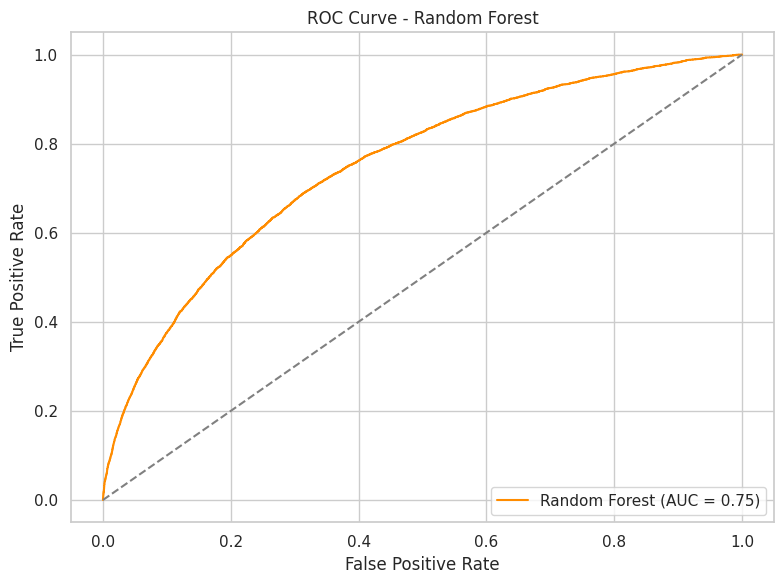

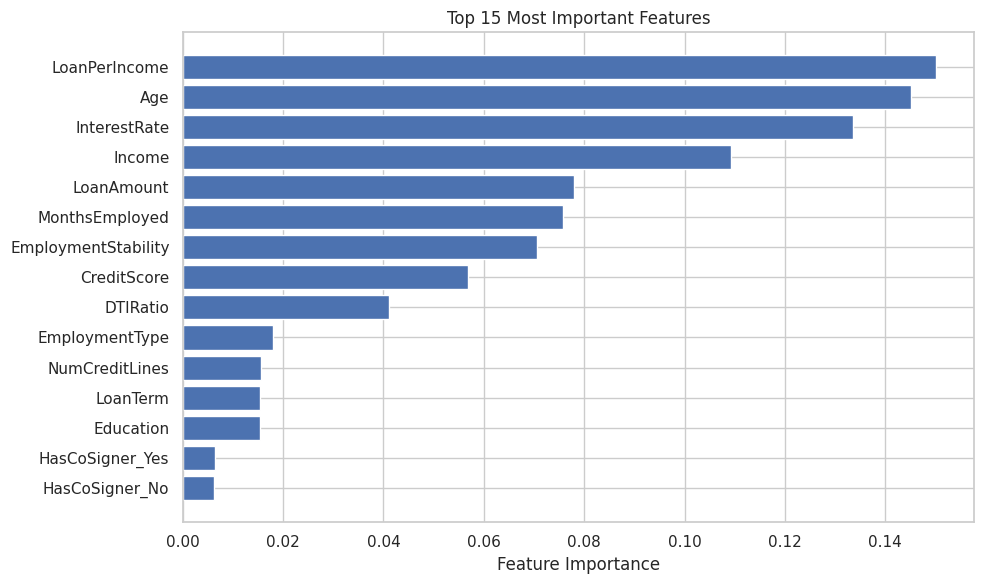

In [ ]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_probs):.2f})', color='darkorange')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Importance
importances = best_rf.feature_importances_
feature_names = X_train.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot top 15 features:
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'][:15], feat_imp_df['Importance'][:15])
plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Features')
plt.gca().invert_yaxis()  # Highest importance on top
plt.tight_layout()
plt.show()

### **3. Tree Model Option 2: XGBoost (Boosting)**


##### **What is XGBoost?**

We now move on to another powerful algorithm: XGBoost. Boosting is yet another ensemble learning technique; however, it is very different from bagging (like Random Forest)! Boosting method fits the data with a single tree and sequentially update the tree based on the errors it made in previous iterations. XGBoost, standing for Extreme Gradient Boosting, is one of the most widely used version of the boosting model.

##### **Why XGBoost is a Good Choice for Loan Default Prediction?**

- **Performs well with imbalanced datasets**  
  Just like Random Forest, XGBoost can handle imbalanced datasets better than models like Logistic Regression as it includes built-in functions that weakens the effects from the majority class.
- **Reduces overfitting**  
  XGBoost reduces overfitting with its regularization methods. It keeps the model relatively simple, but does not lose the incredible predictive power.
- **Provides feature importance**  
  Like Random Forest, XGBoost can also identify which features are most predictive!
- **Captures non-linear relationships**  
Just like Random Forest, as a tree model, XGBoost is naturally good at capturing non-linear patterns between features.

##### **Construct The Base Model**

Just like we did for the previous models, let's build a default XGBoost model to see the benchmark performance:

In [ ]:
# Build the model with default parameters:
xgb_base = XGBClassifier(objective='binary:logistic',
                    eval_metric='logloss',
                    random_state=42)

xgb_base.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
# Predictions on test set:
y_pred = xgb_base.predict(X_test)
y_probs = xgb_base.predict_proba(X_test)[:, 1]

# Model evaluation with confusion matrix, accuracy score, f-1 score and roc curve:

# General accuracy:
print("--------------------------------------------------")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"ROC Area Under Curve: {roc_auc_score(y_test, y_probs)}")

# F-1 score:
print(f"F-1 Score: {f1_score(y_test, y_pred)}")

# Confusion matrix:
cm = confusion_matrix(y_test, y_pred)

print("--------------------------------------------------")
print("Confusion Matrix for Base XGBoost:")
cm_df = pd.DataFrame(cm,
                     index=['Actual_0', 'Actual_1'],
                     columns=['Pred_0', 'Pred_1'])
print(cm_df)
print("--------------------------------------------------")

--------------------------------------------------
Accuracy Score: 0.885549246132759
ROC Area Under Curve: 0.7444763240904957
F-1 Score: 0.14634146341463414
--------------------------------------------------
Confusion Matrix for Base XGBoost:
          Pred_0  Pred_1
Actual_0   44724     415
Actual_1    5430     501
--------------------------------------------------


The accuracy is very high (almost 89%) and the ROC area under curve is around 0.74. However, the F-1 score is very low, particularly because of low recall (having too many False Negatives) just like the results in previous models.

So, now we can conclude that no matter how strong the model is, the imbalance issue is always a significant problem and we can't evaluate model performance solely on accuracy score which again can be very misleading. In the next two sections, let's try our best to mitigate this issue with different strategies.

##### **Dealing with Imbalance: SMOTE**

Synthetic Minority Oversampling Technique, or SMOTE, is a popular approach to deal with imbalanced datasets. We won't go into the details of how SMOTE works here, but the high level idea is that it oversamples the minority class by generating synthetic samples that are close in the feature space of randomly selected minority samples in the original dataset. Combined with the default XGBoost model, let's see if the model yields better results this time:

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Train XGBoost again!
xgb_resampled = XGBClassifier(objective='binary:logistic',
                              eval_metric='logloss',
                              random_state=42)

xgb_resampled.fit(X_train_resampled, y_train_resampled)

# Predictions on test set:
y_pred_resampled = xgb_resampled.predict(X_test)
y_probs_resampled = xgb_resampled.predict_proba(X_test)[:, 1]

# Model evaluation with confusion matrix, accuracy score, f-1 score and roc curve:

# General accuracy:
print("--------------------------------------------------")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_resampled)}")
print(f"ROC Area Under Curve: {roc_auc_score(y_test, y_probs_resampled)}")

# F-1 score:
print(f"F-1 Score: {f1_score(y_test, y_pred_resampled)}")

# Confusion matrix:
cm = confusion_matrix(y_test, y_pred_resampled)

print("--------------------------------------------------")
print("Confusion Matrix for Base XGBoost + SMOTE:")
cm_df = pd.DataFrame(cm,
                     index=['Actual_0', 'Actual_1'],
                     columns=['Pred_0', 'Pred_1'])
print(cm_df)
print("--------------------------------------------------")

--------------------------------------------------
Accuracy Score: 0.8849422361464656
ROC Area Under Curve: 0.745531779879284
F-1 Score: 0.1401814457126134
--------------------------------------------------
Confusion Matrix for Base XGBoost + SMOTE:
          Pred_0  Pred_1
Actual_0   44715     424
Actual_1    5452     479
--------------------------------------------------


From the results above, we can see that SMOTE didn't really help us too much. A potential reason for that can be the fact that there are too many synthetic samples that need to be generated (while the minority class does not have a very clear pattern to be easily generalized).

##### **Dealing with Imbalance: Balanced Class Weights**

Let's now try the alternative approach. Here, we mitigate the effect of imbalanced target variable by introducing a scaled weight parameter to the model. Scikit-Learn has a tool called compute_class_weight, where if we set class_weight to 'balanced', it will help replicating the minority class until having the same samples as the dominating class during modeling. We can calculate the weights (ratio) of 0 class vs. 1 class, and use the scale_pos_weight parameter to inform XGBoost that it should use extra caution to deal with the imbalance issue by looking at the ratio we provide to it.

In [ ]:
# Calculate the weights/ratio of 0 class vs. 1 class:
classes = np.unique(y_train)
weights = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

# Tell XGBoost to pay attention to the class weight:
xgb_scaled = XGBClassifier(objective='binary:logistic',
                           eval_metric='logloss',
                           scale_pos_weight=weights[1],
                           random_state=42)

xgb_scaled.fit(X_train, y_train)

# Predictions on test set:
y_pred_scaled = xgb_scaled.predict(X_test)
y_probs_scaled = xgb_scaled.predict_proba(X_test)[:, 1]

# Model evaluation with confusion matrix, accuracy score, f-1 score and roc curve

# General accuracy:
print("--------------------------------------------------")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_scaled)}")
print(f"ROC Area Under Curve: {roc_auc_score(y_test, y_probs_scaled)}")

# F-1 score:
print(f"F-1 Score: {f1_score(y_test, y_pred_scaled)}")

# Confusion matrix:
cm = confusion_matrix(y_test, y_pred_scaled)

print("--------------------------------------------------")
print("Confusion Matrix for XGBoost with Weight Balance Control:")
cm_df = pd.DataFrame(cm,
                     index=['Actual_0', 'Actual_1'],
                     columns=['Pred_0', 'Pred_1'])
print(cm_df)
print("--------------------------------------------------")

--------------------------------------------------
Accuracy Score: 0.8156060309379284
ROC Area Under Curve: 0.7434351817951308
F-1 Score: 0.35380498181568654
--------------------------------------------------
Confusion Matrix for XGBoost with Weight Balance Control:
          Pred_0  Pred_1
Actual_0   39075    6064
Actual_1    3353    2578
--------------------------------------------------


We can see from the results above that the F-1 score significantly increased! This is a great improvement, especially considering that the trade-off on accuracy and the ROC AUC does not look large at all. By looking at the confusion matrix, we can clearly see that now we have far fewer False Negatives.

##### **XGBoost Hyperparameter Tuning with Grid Search**

Finally, let's put everything useful together - grid search for hyperparameter tuning! In the section below we will use stratified cross validation, which maintains stratified folds that keep the percentage of 0 class and 1 class consistent.

In [ ]:
# Parameter grid to tune XGBoost:
param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.01, 0.001]
}

# Stratified K-Fold:
stratified_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Perform grid search and score on auc/f-1 score:
grid_search = GridSearchCV(estimator=xgb_scaled,
                           param_grid=param_grid,
                           cv=stratified_cv,
                           scoring='roc_auc',
                           verbose=1)

grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 27 candidates, totalling 270 fits


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importan...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             param_grid={'learning_rate': [0.1, 0.01, 0.001],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc', verbose=1)

In [ ]:
# Best model:
best_xgb = grid_search.best_estimator_
best_xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

We saw that the optimal n_estimators is 200, which in XGBoost means that the model will do 200 boosting rounds on the initial tree. The max tree depth for the base learner will be 3, and learning rate is set to a relatively large number of 0.1. Let's use these tuned parameters to build the final model and evaluate its performance below:

In [ ]:
# Predictions on test set:
y_pred_best = best_xgb.predict(X_test)
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

# Model evaluation with confusion matrix, accuracy score, f-1 score and roc curve

# General accuracy:
print("--------------------------------------------------")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_best)}")
print(f"ROC Area Under Curve: {roc_auc_score(y_test, y_pred_proba)}")

# F-1 score:
print(f"F-1 Score: {f1_score(y_test, y_pred_best)}")

# Confusion matrix:
cm = confusion_matrix(y_test, y_pred_best)

print("--------------------------------------------------")
print("Confusion Matrix for XGBoost with Weight Balance Control:")
cm_df = pd.DataFrame(cm,
                     index=['Actual_0', 'Actual_1'],
                     columns=['Pred_0', 'Pred_1'])
print(cm_df)
print("--------------------------------------------------")

--------------------------------------------------
Accuracy Score: 0.8160172312512238
ROC Area Under Curve: 0.7601738579962276
F-1 Score: 0.3739339019189765
--------------------------------------------------
Confusion Matrix for XGBoost with Weight Balance Control:
          Pred_0  Pred_1
Actual_0   38868    6271
Actual_1    3125    2806
--------------------------------------------------


From the results shown above, we can clearly see that the F-1 score increased again, from 0.354 to 0.374! We now have even fewer False Negatives in the test set, and the accuracy score/ROC AUC maintains at a decent level, suggesting that our model does not overfit the data. We will visualize the results next.

##### **ROC Curve and Top Features Visualization**

Here we plot the ROC curve and feature importance just like we did in the Random Forest section:

-	The AUC (Area Under Curve) = 0.76 is a slight improvement from the Random Forest result.
-	The Top 3 features are Age, LoanPerIncome, and InterestRate, which are the same as the results from Random Forest, just in different orders. Generally, we can say that both tree models agree on the most important features, and banks can very well use these as predictors when dealing with defaults.

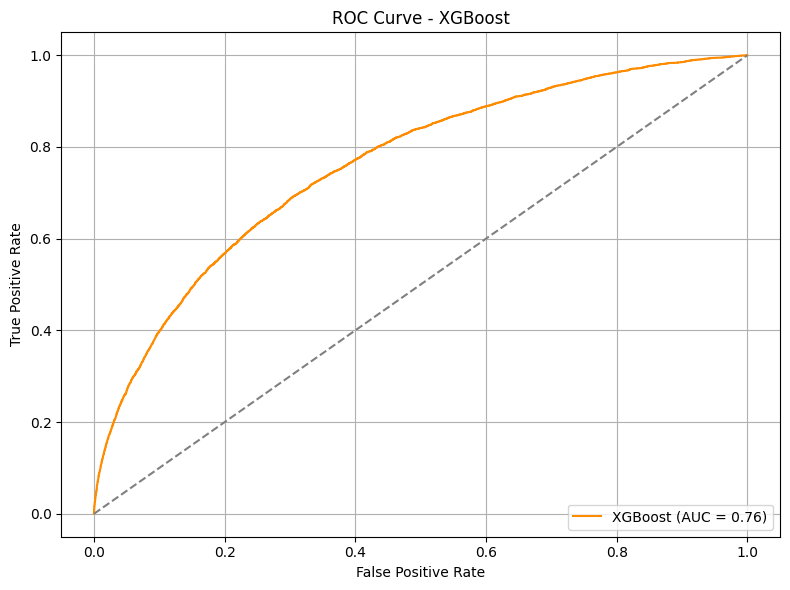

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})', color='darkorange')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

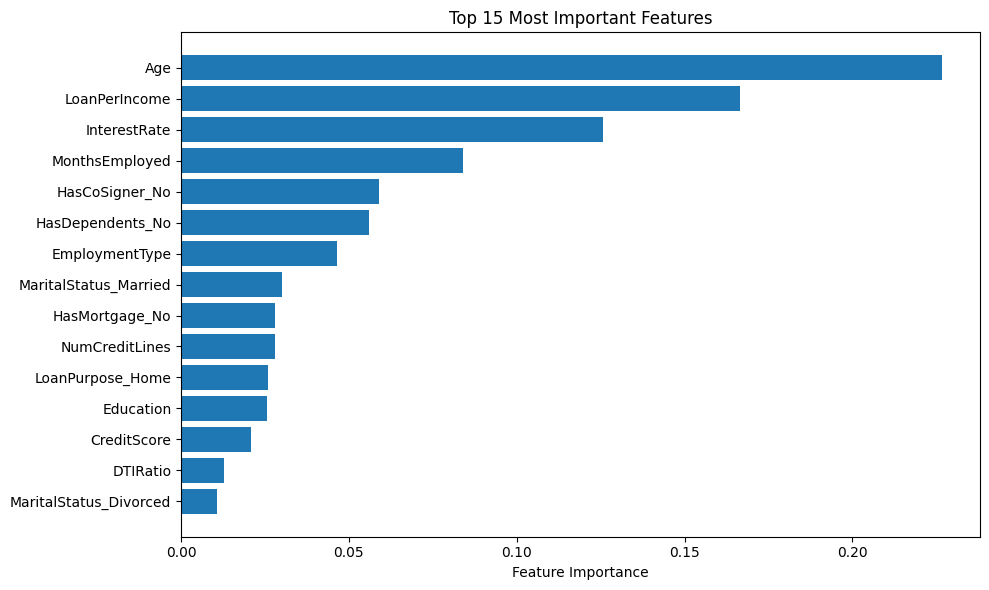

In [ ]:
# Feature Importance
importances = best_xgb.feature_importances_
feature_names = X_train.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

#plot top 15
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'][:15], feat_imp_df['Importance'][:15])
plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Features')
plt.gca().invert_yaxis()  # Highest importance on top
plt.tight_layout()
plt.show()

## **VI. Result Interpretation**

Some key findings from the Exploratory Data Analysis (EDA) revealed that the target variable—loan default is highly imbalanced, with significantly more non-default cases than defaults. Additionally, input features showed low correlation with one another, suggesting minimal multicollinearity and a diverse feature space.

Based on these insights, Logistic Regression was selected as a baseline model due to its simplicity, interpretability, and suitability for binary classification. Given the imbalance in the target variable, ensemble tree-based models such as Random Forest and XGBoost were chosen for further experimentation, as they are better equipped to handle class imbalance and capture complex, nonlinear relationships in the data.

It is worth noting that the top three most important features remain consistent across the final versions of all three models: Logistic Regression, Random Forest, and XGBoost. These features are **Age**, **LoanPerIncome**, and **InterestRate**, although their ranking varies slightly between models.

This consistency is particularly interesting given the different architectures of the models. Logistic Regression being linear, while Random Forest and XGBoost are tree-based and capable of capturing non-linear interactions. All models prioritize the same features. This reinforces confidence in the robustness and importance of these three variables.

The slight variations in feature rankings are also insightful. Logistic Regression assigns linear weights, whereas tree-based models capture complex interactions and non-linearities. Thus, the differences in ranking reflect how each model interprets the same underlying data in distinct ways.

Model Performance Comparison:
              Model  Accuracy  ROC AUC  Precision (Class 1)  Recall (Class 1)  F1 Score (Class 1)
Logistic Regression    0.6896   0.7599               0.2274            0.6975              0.3429
Random Forest (0.4)    0.5783   0.7560               0.1895            0.8043              0.3086
            XGBoost    0.8160   0.7602               0.3104            0.4727              0.3739


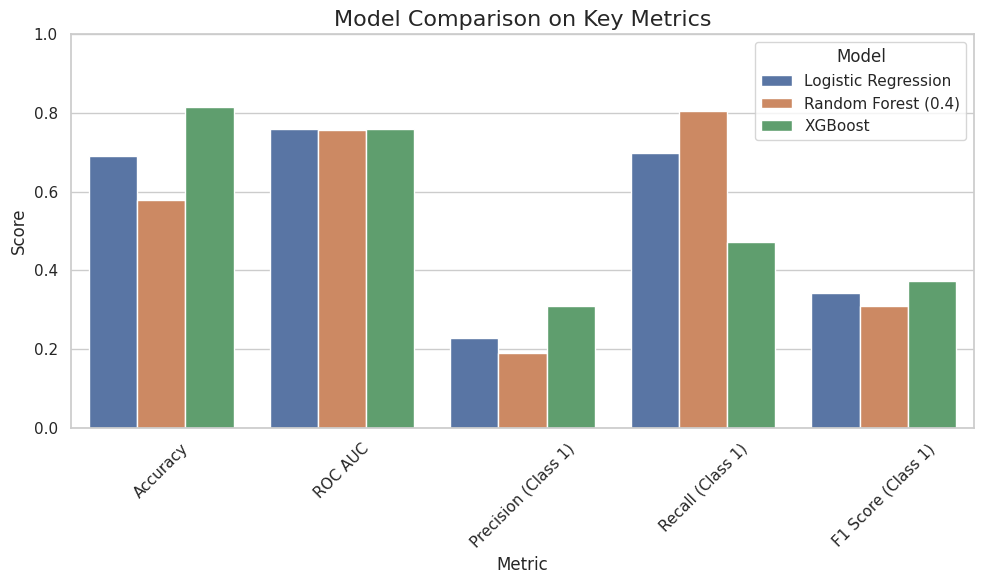

In [ ]:
sns.set(style="whitegrid")

# manually create a df
data = {
    "Model": ["Logistic Regression", "Random Forest (0.4)", "XGBoost"],
    "Accuracy": [0.6896, 0.5783, 0.8160],
    "ROC AUC": [0.7599, 0.756, 0.7602],
    "Precision (Class 1)": [0.2274, 0.1895, 0.3104],
    "Recall (Class 1)": [0.6975, 0.8043, 0.4727],
    "F1 Score (Class 1)": [0.3429, 0.3086, 0.3739]
}

df = pd.DataFrame(data)

# Display the table
print("Model Performance Comparison:")
print(df.to_string(index=False))

df_melt = df.melt(id_vars="Model", var_name="Metric", value_name="Score")


plt.figure(figsize=(10, 6))
sns.barplot(data=df_melt, x="Metric", y="Score", hue="Model")
plt.title("Model Comparison on Key Metrics", fontsize=16)
plt.xticks(rotation=45)
plt.ylim(0, 1.0)
plt.legend(title="Model", loc='upper right')
plt.tight_layout()
plt.show()


Finally, let's compare our models:

**Logistic Regression (Modified Hyperparameter Tuning)**

The tuned logistic regression model achieved approximately 68.96% accuracy and a ROC AUC of 0.7599. It showed strong recall (0.6975), meaning it was effective at identifying actual defaults—an important metric in loan risk prediction. However, the model’s precision (0.2274) was relatively low, indicating a higher number of false positives. Overall, this model is suitable when the priority is on capturing as many defaulters as possible, even if it results in some incorrect default predictions.


**Random Forest (Threshold = 0.4)**

By adjusting the threshold to 0.4, the random forest model achieved the highest recall (0.8043), making it the most aggressive in flagging defaults. However, this came at the cost of lower overall accuracy (57.83%) and reduced precision (0.1885). This approach is beneficial in scenarios where it is critical not to miss any potential defaulters, though it may result in a higher number of false positives.


**Stratified XGBoost**

XGBoost demonstrated the most balanced performance across metrics, with approximately 81.60% accuracy, a ROC AUC of 0.7602, and the highest F1-score (0.3739). It offered a strong balance between recall and precision, making fewer incorrect predictions while still capturing a substantial number of actual defaults. This model stands out as a strong candidate when both performance and predictive stability are desired.


**Final Thoughts**

Since our goal is to predict loan defaults, both precision and recall matter. So we can catch defaulters without falsely rejecting too many good applications. Thus, XGBoost offers the best balance - it has strong ROC AUC and F1-score for minority class and has good overall accuracy too.



## **VII. Challenges**

**Severe Class Imbalance**

The dataset has a significant imbalance between non-default and default cases, which caused initial baseline models with default parameters to perform poorly, particularly in detecting defaults. This led to very low recall and F1-scores for the minority class, highlighting the need to address class imbalance during model training. Several approaches were explored to handle this: using class_weight='balanced' significantly improved performance on the default class for logistic regression. For XGBoost, we also experimented with changing the evaluation metric to AUCPR (Area Under the Curve for Precision and Recall), but found the results to be nearly identical to log-loss, so we chose to stick with the latter for consistency. Additionally, for XGBoost, we attempted to implement a custom weighted log-loss function to better penalize misclassifications of the minority class, but this approach didn’t yield meaningful improvements. Ultimately, we found that standard log-loss combined with class weighting provided a practical and effective solution to the imbalance issue.


**Balancing Model Performance vs. Computational Efficiency**

Extensive hyperparameter tuning (e.g., large GridSearchCV) can be very time-consuming, especially on large datasets. A trade-off had to be made between model performance and training time, leading to the use of statistical tests (e.g., t-tests) to determine whether deeper tuning was statistically justified.

## **VIII. Discussions & Potential Next Steps**


#### **1. More Models?**

**Unsupervised Learning**

* Although we are tackling a classification problem, there are some unsupervised learning methods that can definitely be helpful in terms of understanding the dataset better. While time does not allow us to conduct the entire analysis, it is worth to point out that algorithms like K-means Clustering are great ways to group similar data points into the same clusters and identify if they have any features particularly in common.

**Why not other classic ML models like Support Vector Machine (SVM)?**

* There are a lot of ML models widely used by Data Scientists for various kinds of classification problems. So, why did we only try Logistic Regression, Random Forest, and XGBoost, but not other classic models like SVM? This ties to the challenge of having an imbalanced dataset mentioned above - models like SVM would prioritize making correct decisions towards the majority class, shifting the margin/decision boundary towards it. Hence, we picked two powerful tree models that can handle imbalance issue better and used Logistic Regression as the benchmark for comparison purposes.

**Deep Learning Approaches**

* We can definitely experiment with Neural Networks (especially if the dataset grows or gains more complex features). However, super complicated Neural Network models can result in severe overfitting.

#### **2. Other Available Future Steps**

Here are some other potential next steps we can do, given that we have more time and resources:

**Deploy the Model**

* Package the final model into a REST API using Flask or FastAPI.

* Create a simple front-end dashboard (Streamlit or Dash) for users to test predictions.

**Monitoring & Feedback Loop**

* Set up a feedback loop to monitor live performance and retrain the model over time.

* Track model drift and update data regularly for retraining.

**Testing with Real-World Scenarios**

* Validate model predictions against real or simulated customer data.

* Perform stress testing with edge cases (e.g., very high DTI, low income but high credit score, etc.).